In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv("NASDAQ_100_Data_From_2010.csv", sep="\t")
df["Date"] = pd.to_datetime(df["Date"])

# 2. Data Reshaping (Pivot Table)
price_matrix = df.pivot(index="Date", columns="Name", values="Adj Close")

# 3. Return Transformation (Daily Log Returns)
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# 4. Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
clean_returns = returns_matrix.dropna(axis=1)

# 5. Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns).T
stock_names = clean_returns.columns.tolist()


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ==========================================
# 6. กำหนดจำนวน Cluster (k = 3) และรัน K-Means แบบปกติ (ไม่ผ่าน PCA)
# ==========================================
k = 3  # ปรับจำนวนกลุ่มเป้าหมายเป็น 3 กลุ่มตามที่กำหนด

# 6.1 รัน K-Means โดยตรงบนข้อมูล Return Profile (X)
kmeans_raw = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X)

# 6.2 คำนวณ Silhouette Score เพื่อวัดความแน่นหนาของการจัดกลุ่ม
score_raw = silhouette_score(X, clusters_raw)
print(f"Silhouette Score (Standard K-Means, k=3): {score_raw:.4f}")

Silhouette Score (Standard K-Means, k=3): 0.0350


C:\Users\thiti\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
# ==========================================
# 7. ทำ PCA เพื่อลดมิติข้อมูล แล้วรัน K-Means (PCA + K-Means, k=3)
# ==========================================
# 7.1 ลดมิติข้อมูลอนุกรมเวลา (Daily Returns) ให้เหลือ 2 Principal Components เพื่อการสร้างกราฟ 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# ดูสัดส่วนข้อมูลที่ PCA 2 มิตินี้อธิบายได้ (Variance Ratio)
explained_var = pca.explained_variance_ratio_.sum()
print(f"Explained Variance (PCA 2 Components): {explained_var:.2%}")

# 7.2 รัน K-Means บน PCA Components ด้วย k = 3
kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# 7.3 คำนวณ Silhouette Score บน PCA Space
score_pca = silhouette_score(X_pca, clusters_pca)
print(f"Silhouette Score (PCA + K-Means, k=3): {score_pca:.4f}")

Explained Variance (PCA 2 Components): 12.65%
Silhouette Score (PCA + K-Means, k=3): 0.4512


C:\Users\thiti\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


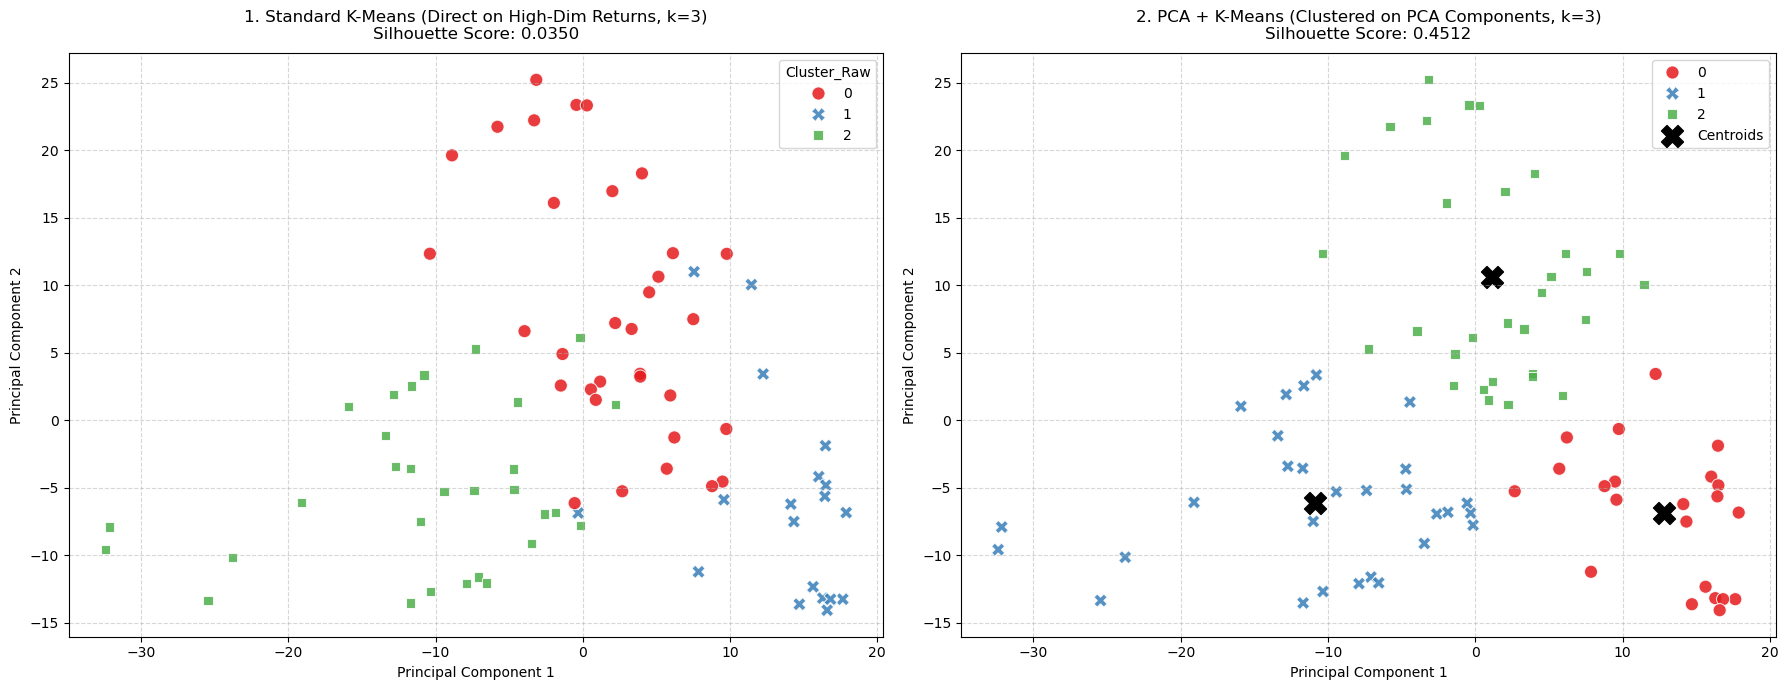

In [11]:
# ==========================================
# 8. สรุปผลลัพธ์ใส่ DataFrame
# ==========================================
df_results = pd.DataFrame(
    {
        "Stock": stock_names,
        "Cluster_Raw": clusters_raw,
        "Cluster_PCA": clusters_pca,
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
    }
)

# ==========================================
# 9. สร้าง กราฟเปรียบเทียบ (Visualization)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 9.1 Plot 1: Standard K-Means (k=3)
sns.scatterplot(
    ax=axes[0],
    x=df_results["PC1"],
    y=df_results["PC2"],
    hue=df_results["Cluster_Raw"],
    palette="Set1",
    style=df_results["Cluster_Raw"],
    s=90,
    alpha=0.85,
)
axes[0].set_title(
    f"1. Standard K-Means (Direct on High-Dim Returns, k=3)\nSilhouette Score: {score_raw:.4f}",
    fontsize=12,
    pad=10,
)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 9.2 Plot 2: PCA + K-Means (k=3)
sns.scatterplot(
    ax=axes[1],
    x=df_results["PC1"],
    y=df_results["PC2"],
    hue=df_results["Cluster_PCA"],
    palette="Set1",
    style=df_results["Cluster_PCA"],
    s=90,
    alpha=0.85,
)
# วาดจุดศูนย์กลางกลุ่ม (Centroids) บน PCA Space
centroids_pca = kmeans_pca.cluster_centers_
axes[1].scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="black",
    marker="X",
    label="Centroids",
)

axes[1].set_title(
    f"2. PCA + K-Means (Clustered on PCA Components, k=3)\nSilhouette Score: {score_pca:.4f}",
    fontsize=12,
    pad=10,
)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# 10. นับจำนวนหุ้นในแต่ละ Cluster ของ PCA + K-Means
# ==========================================
print("\n--- สรุปจำนวนหุ้นในแต่ละกลุ่ม (PCA + K-Means, k=3) ---")
print(df_results["Cluster_PCA"].value_counts().sort_index())

print("\n--- ตัวอย่างรายชื่อหุ้นในแต่ละ Cluster ---")
for c in range(k):
    stocks_in_cluster = df_results[df_results["Cluster_PCA"] == c]["Stock"].tolist()
    print(f"Cluster {c} ({len(stocks_in_cluster)} หุ้น): {stocks_in_cluster[:10]}...")


--- สรุปจำนวนหุ้นในแต่ละกลุ่ม (PCA + K-Means, k=3) ---
Cluster_PCA
0    22
1    29
2    31
Name: count, dtype: int64

--- ตัวอย่างรายชื่อหุ้นในแต่ละ Cluster ---
Cluster 0 (22 หุ้น): ['AAPL', 'ADI', 'ADSK', 'AMAT', 'AMD', 'ANSS', 'ASML', 'AVGO', 'CDNS', 'INTC']...
Cluster 1 (29 หุ้น): ['ADP', 'AEP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR']...
Cluster 2 (31 หุ้น): ['ADBE', 'ALGN', 'AMGN', 'AMZN', 'ATVI', 'BIDU', 'BIIB', 'BKNG', 'CERN', 'CHKP']...
